In [ ]:
#!/bin/bash 
cd '/Users/cylam/Desktop/U of T PhD (2020-)/DSI Certificate/20260601_visualization'
source visualization-env/bin/activate

In [2]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [ ]:
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

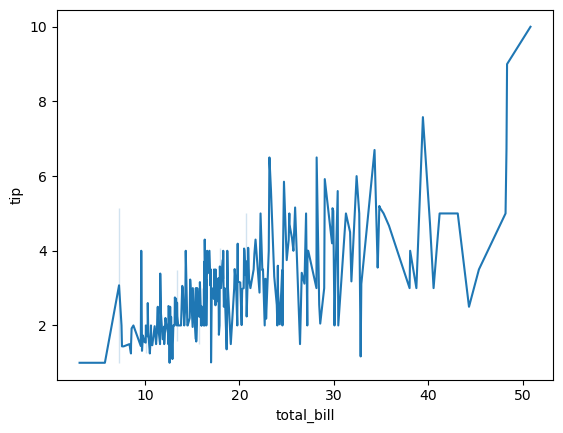

In [ ]:
#using seaborn: similar to matplotlib, but helps handle semantic mapping 

sns.lineplot(data=tips, # choose our dataset
x='total_bill', # define our x variable
y='tip') # define our y variable

<Axes: xlabel='total_bill', ylabel='tip'>

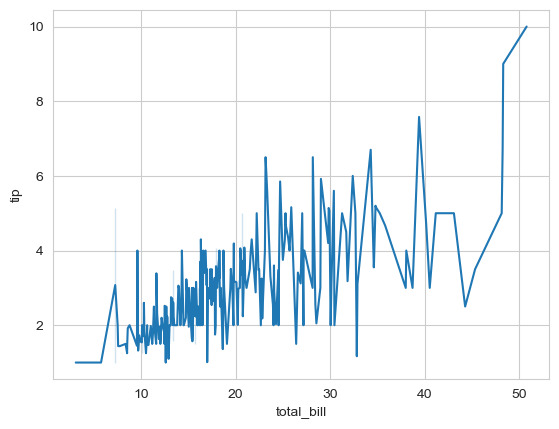

In [ ]:
#alter graph appearance with premade styles 
sns.set_style('whitegrid')

sns.lineplot(data=tips, x='total_bill', y='tip') 

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

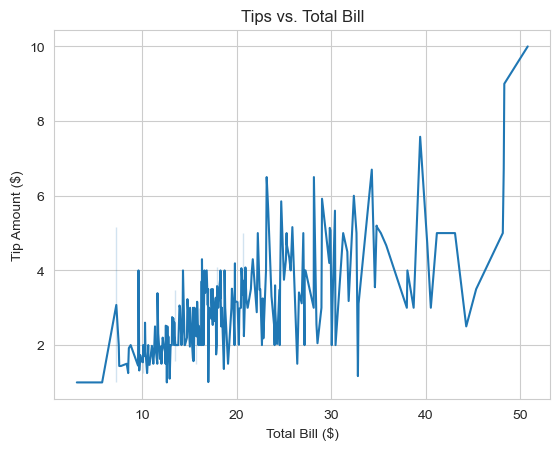

In [ ]:
#add labels using set function 
#first save the graph as a new var 
tipgraph = sns.lineplot(data=tips, x='total_bill', y='tip')

tipgraph.set(title='Tips vs. Total Bill', xlabel='Total Bill ($)', ylabel='Tip Amount ($)')

#note the whitegrid style called in the previous code chunk carries over


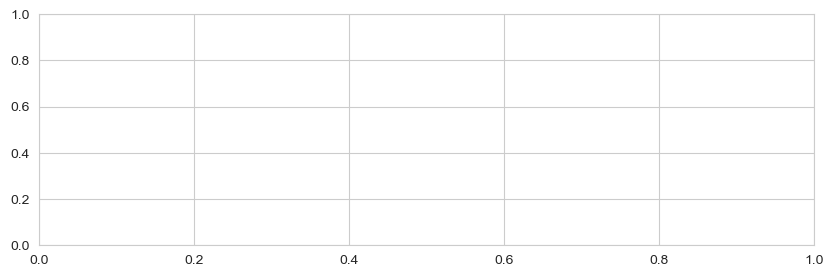

In [ ]:
#change figure size is the same as in matplotlib

fig = plt.subplots(figsize=(10, 3))

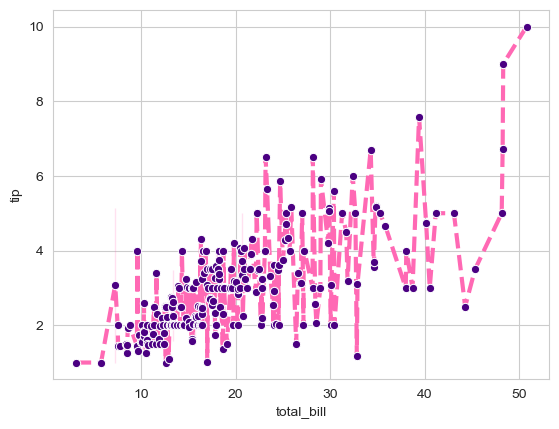

In [ ]:
#customizing color, marker shapes & style, line shape & style 

tipgraph = sns.lineplot(data=tips,
x='total_bill', y='tip', color = 'hotpink', linestyle = '--', linewidth = 3, marker = 'o', markerfacecolor = 'indigo')

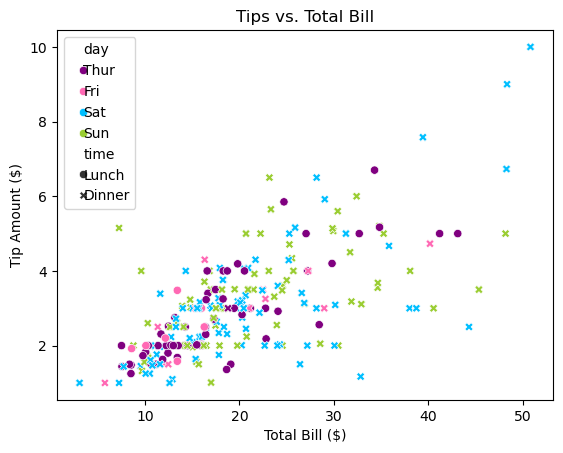

In [ ]:
#so why is seaborn an improvement over matplotlib? 
#much easier to represent multiple variables from a df with various visual elements in the graph (here x, y, style, hue)

tipgraph = sns.scatterplot(data = tips, x = "total_bill", y = "tip", 
                           style = "time", #marker shape 
                           hue = "day", #marker color
                           palette = ['purple', 'hotpink', 'deepskyblue', 'yellowgreen']) #palette for hue 

tipgraph.set(title = 'Tips vs. Total Bill', 
             xlabel = 'Total Bill ($)', 
             ylabel = 'Tip Amount ($)')

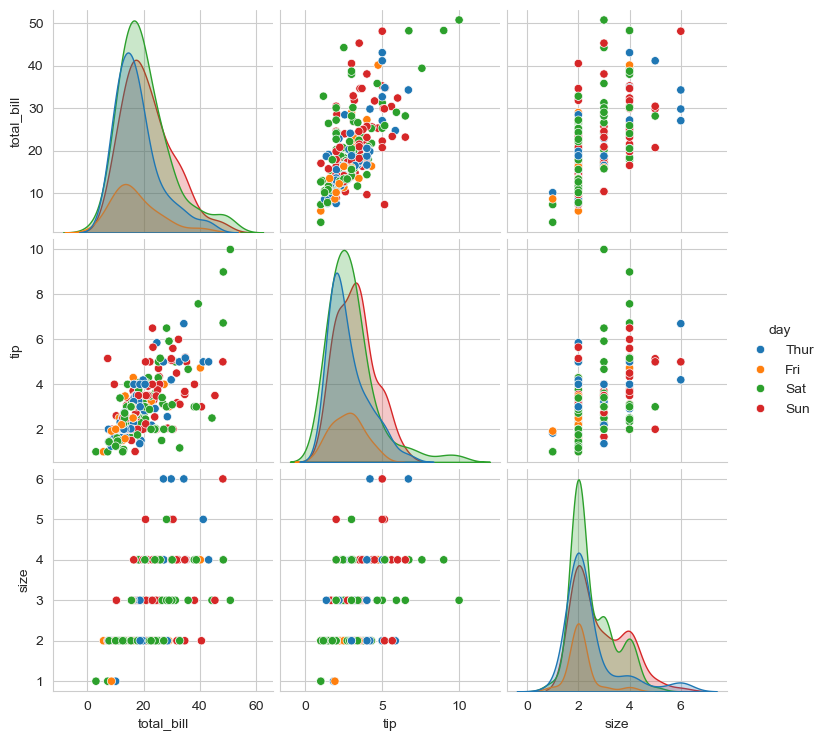

In [ ]:
#pairplot automatically plots all quantitative data columns in the df against each other, except any quantitative cols called in hue / style / other visual elements 
#(e.g. if I set hue = size, then the pairplot would be 2x2 and size would not show up as one of the pairwise comparisons)
sns.pairplot( 
    data = tips,
    hue = 'day')

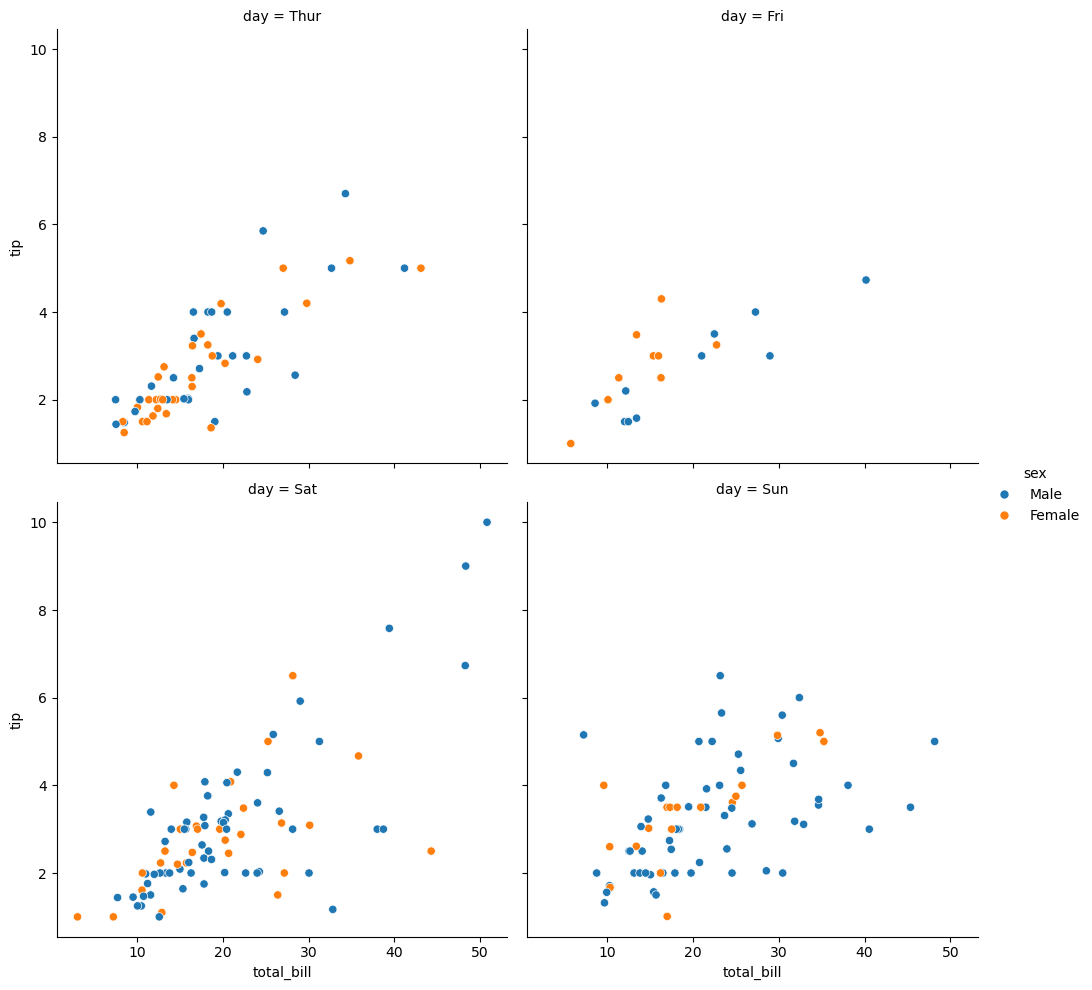

In [ ]:
#relplot lets us explore specific levels within variables
#e.g. here by setting col = day, each day is given its own plot 
#obvs usually applied to categorical variables - if you use it on quantitative data it could crash your VS Code!

daysplot = sns.relplot(
    data=tips,
    x="total_bill", 
    y="tip", 
    hue="sex", #color of the data points is the sex of the tipper 
    col="day", #day is the variable chosen to separate into individual plots
    kind="scatter", #type of plot 
    col_wrap=2) #specifies max number of plots in each row, so that additional plots are 'wrapped' into the next row 

In [ ]:
#Using Plotly
#Plotly makes interactive plots 

import plotly.graph_objects as go  #'go' stands for 'graph objects’

In [ ]:
#load data
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [ ]:
#make the figure 
graph = go.Figure()

#choose plot type (bar) and data 
graph.add_trace(go.Bar(x=x1, y=y1))



In [ ]:
#add titles 
graph.update_layout(
title="Pirate Scores", xaxis_title="Pirates", yaxis_title="Score")
graph.show()

In [ ]:
#customizing visual aesthetics 
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers', # we want points for a scatter plot
                           marker=dict(
                               size=15, # point size
                               color='hotpink', # point colour
                               opacity=1, # point transparency/alpha
                               line=dict(width=5, color='purple') # point outline
                               )
                            ))

graph.update_layout(
    title='Interactive Pirate Plot', 
    xaxis_title='Pirates', 
    yaxis_title='Scores',
    width=500, height=500)

In [ ]:
from wordcloud import WordCloud

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv", 
                 on_bad_lines = 'skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

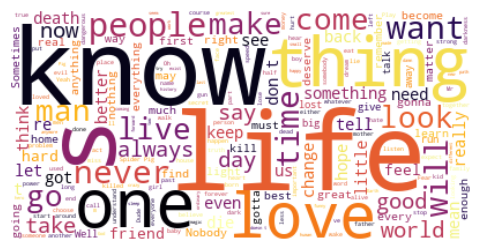

In [ ]:
# join all our text from each row from our quote column into a string
text = " ".join(each for each in df.quote)

# generate our wordcloud image
#WordCloud automatically counts the number of times each string appears and makes strings that appear often have larger font size 
wordcloud = WordCloud(background_color="white", 
                      colormap = 'inferno').generate(text)

# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud,  # remember 'imshow' from when we added pictures to our matplotlib axes
          interpolation='bilinear') ## this line helps smooth our image
ax.axis("off") #hides the axes labels 

#you can re-run this code chunk as each time the viz will look different!

In [ ]:
#Venn diagram 

from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [ ]:
#define sets 

A = set(["apple", "banana", "watermleon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

/Users/cylam/Desktop/U of T PhD (2020-)/DSI Certificate/20260601_visualization/.venv/lib/python3.11/site-packages/matplotlib_venn/_util.py:32: UserWarning: venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.
  warnings.warn(


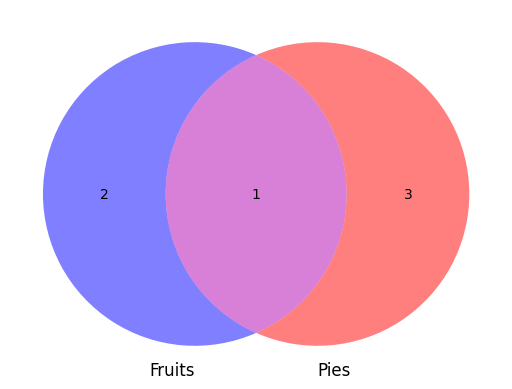

In [ ]:
#assign our sets to each circle and modify the appearance

diagram = venn2_unweighted([A, B], 
                           set_labels = ('Fruits', 'Pies'), 
                           set_colors=("blue", "red"), 
                           alpha = 0.5)
plt.show()
#by default, the Venn diagram will only show the count of how many items are in each set 

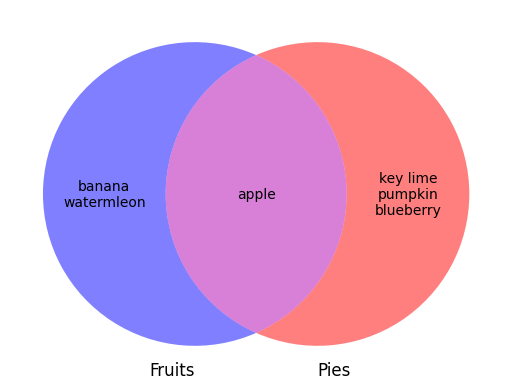

In [ ]:
#can customize this to display labels from our sets, A and B
#"10", "11", "01" refers to the circles or overlapping regions in the diagram (1 means present in the circle, 0 means absent; order is from left to right) 
#\n means labels are separated by a newline character 
# A - B, B - A and A & B refers to the sets defined above (which contain the actual names of the fruits)

diagram = venn2_unweighted([A, B], 
                           set_labels = ('Fruits', 'Pies'), 
                           set_colors=("blue", "red"), 
                           alpha = 0.5)

diagram.get_label_by_id("10").set_text("\n".join(A - B)) #apply labels that are in set A but not B (A - B) to the left circle (10) 
diagram.get_label_by_id("11").set_text("\n".join(A & B)) #apply labels that are in both sets A and B (A & B) to the overlapping region (11)
diagram.get_label_by_id("01").set_text("\n".join(B - A)) #apply laels that are in set B but not A (B - A) to the right circle (01)

plt.show()